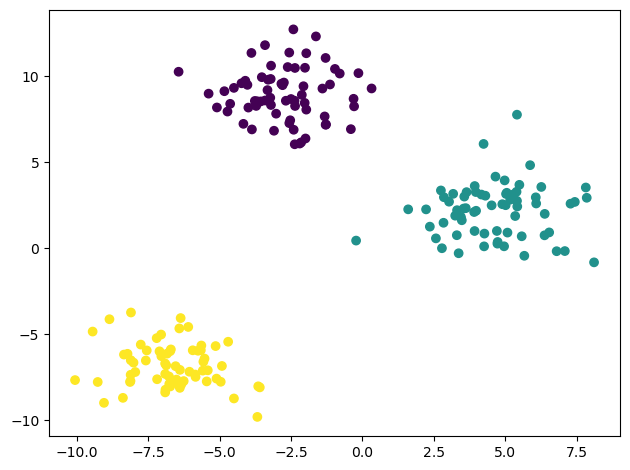

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성
X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)

# 시각화
plt.scatter(X[:,0],X[:,1], c=y)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.cluster import KMeans

k=5
kmeans = KMeans(n_clusters=5)
y_predict = kmeans.fit_predict(X)

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


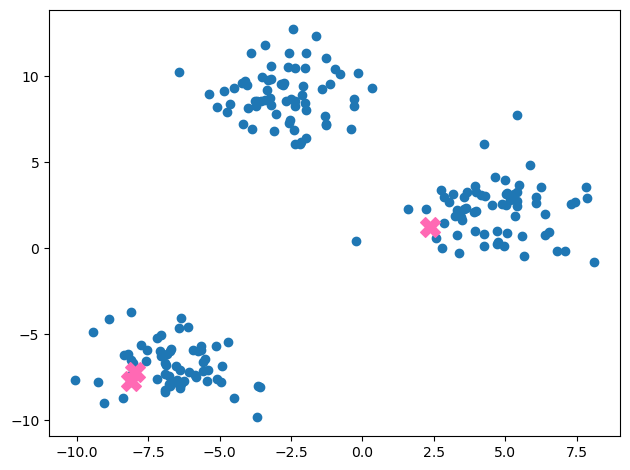

In [7]:
import numpy as np

# step1 - 초기중심: 처음 중심을 랜덤으로 선택
k=3
np.random.seed(42)
indicies = np.random.choice(len(X), k, replace=False)
centroids = X[indicies]
plt.scatter(X[:,0],X[:,1])
plt.scatter(centroids[:,0],centroids[:,1],c='hotpink',marker='X',s=200)
plt.tight_layout()
plt.show()

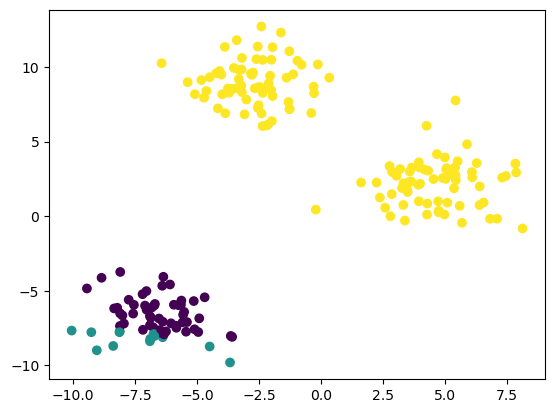

In [14]:
# step2 각 점을 가장 가까운 중심에 할당
# 거리계산 -> 가장 가까운 중심 선택
def assign_cluster(X, centroids):
    distance = np.linalg.norm(X[:, np.newaxis]-centroids, axis=2)
    return np.argmin(distance,axis=1)
labels = assign_cluster(X,centroids)
labels

# 각 점이 0,1,2중 하나로 배정됨
plt.scatter(X[:,0],X[:,1],c=labels)

In [18]:
print(X.shape, X[:,np.newaxis].shape, centroids.shape)
# newaxis 새로운 축 추가
# 점 200개 x centroid 3개 x 좌표2
# 첫번째 점  [1,2]
# centroid : [3,4] [5,6] [7,8]
# [1-3, 2-4] [1-5, 2-6], [1-7, 2-8]
# 모든 centroid와의 좌표계산
# 유클리드거리 (np.linalg.norm)   (x차이**2 + y차이**2)(1/2) axis=2 좌표방향
# np.argmin(distance,axis=1) 가장 가까운 centroid 선택

(200, 2) (200, 1, 2) (3, 2)


In [19]:
# step3 중심이동
# 각 그룹의 평균을 계산 --> 새로운 중심
def update_centroid(X,labels,k):
    return np.array(
        [X[labels==i].mean(axis=0) for i in range(k)]
    )

centroids = update_centroid(X,labels,k)
centroids

array([[-6.52538496, -6.47920158],
       [-7.30160668, -8.29627639],
       [ 0.94735044,  5.54722254]])

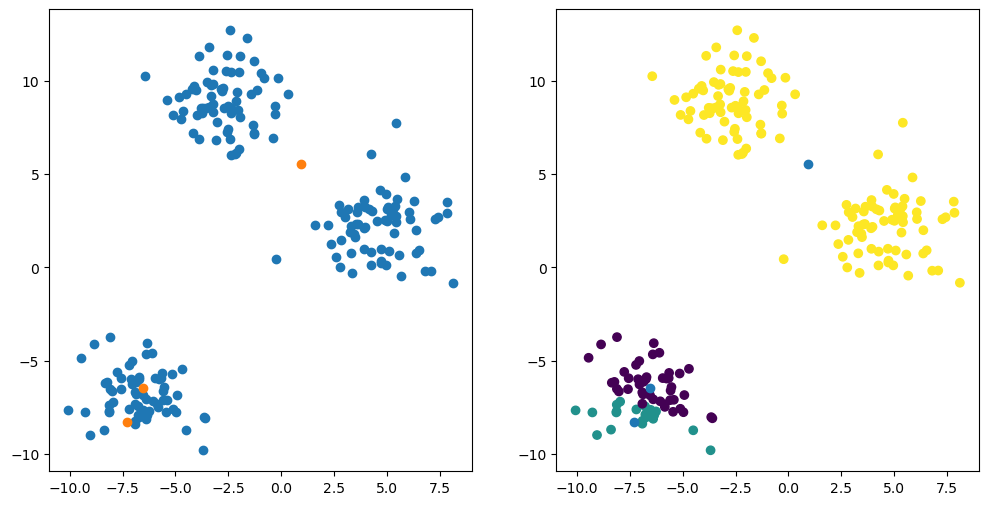

In [30]:
# 새로운 중심점을 좌표에 업데이트
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0],X[:,1]) # 원래 거
ax[0].scatter(centroids[:,0],centroids[:,1]) # 새 중심점

# 새로운 중심점을 기준으로 label을 분리해서 시각화
labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0],X[:,1],c=labels)
ax[1].scatter(centroids[:,0],centroids[:,1])
plt.show()

In [31]:
# 데이터 준비
# 임의의 중심점 생성
# 중심점 주변의 데이터의 라벨을 설정
# 같은 라벨끼리 평균을 구해서 중심점 업데이트
# 새로운 중심점으로 라벨을 할당

# update_centroid
# assign_cluster

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성
X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)


In [32]:
k = 3
indicies = np.random.choice(len(X), k, replace=False)
centroids=X[indicies]

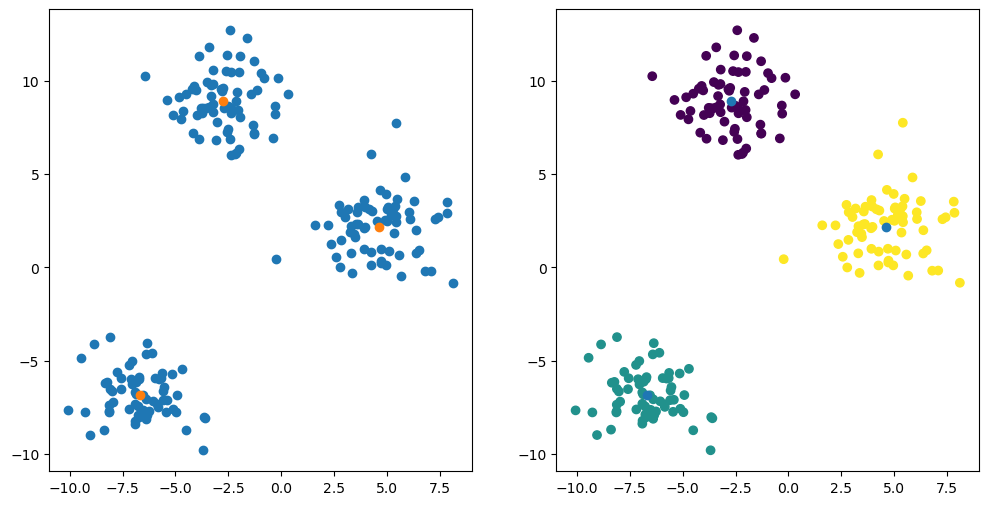

In [37]:
label = assign_cluster(X, centroids)
new_centroid = update_centroid(X, label, k)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0],X[:,1]) # 원래 거
ax[0].scatter(centroids[:,0],centroids[:,1]) # 새 중심점

# 새로운 중심점을 기준으로 label을 분리해서 시각화
labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0],X[:,1],c=labels)
ax[1].scatter(centroids[:,0],centroids[:,1])
plt.show()

centroids = new_centroid

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

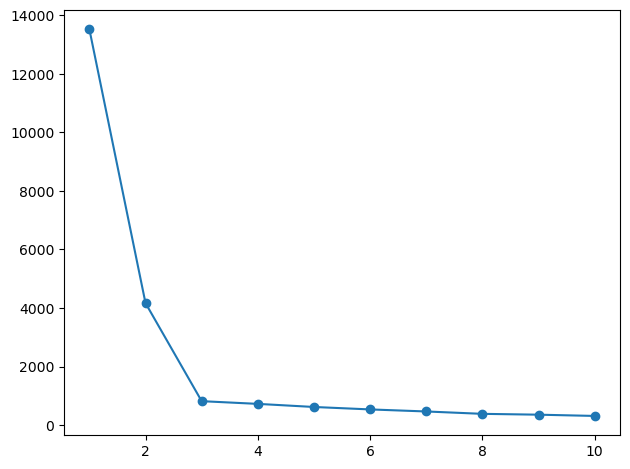

In [42]:
# 최적의 k개수 찾기 - Elbow Method(기본)
# k가 증가할수록 오차는 감소
# ㄴ> WCSS (Within Cluster Some of Square); 각 점과 중심점과의 거리의 제곱의 합
# 어느순간 감소폭이 급격히 줄어듦. --> 줄어든 그 지점

k_range = range(1,11)
wcss = []
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(k_range, wcss,'-o')
plt.tight_layout()
plt.show()

In [38]:
X

array([[ 7.43854060e+00,  2.68391907e+00],
       [-6.43881528e+00,  1.02471399e+01],
       [-6.89799735e+00, -8.22599115e+00],
       [-9.05175370e+00, -8.99130525e+00],
       [-7.76367433e+00, -5.60570645e+00],
       [-5.75868678e+00, -5.96455420e+00],
       [-2.79773907e+00,  9.46660714e+00],
       [-7.58618465e+00, -6.53203469e+00],
       [ 4.24289359e+00,  6.05342343e+00],
       [-5.66033401e+00, -5.93566633e+00],
       [ 3.24948313e+00,  1.88388165e+00],
       [ 4.98106874e+00,  3.93388382e+00],
       [ 6.26445570e+00,  3.55387276e+00],
       [ 3.91183351e+00,  2.09598089e+00],
       [ 1.60216496e+00,  2.25285116e+00],
       [-8.12311971e+00, -7.72038115e+00],
       [-2.61721281e+00,  1.05195855e+01],
       [-8.11295778e+00, -6.51457878e+00],
       [ 5.66926912e+00, -4.45904123e-01],
       [-4.50060197e+00, -8.73683284e+00],
       [ 7.82311313e+00,  3.52186757e+00],
       [ 3.92746087e+00,  9.93175835e-01],
       [-6.39554935e+00, -8.12095601e+00],
       [-2.

In [46]:
# 실루엣 score
# 같은 클러스터끼리는 가깝고 다른 클러스터와는 멀어야 좋다 범위는 -1~1

from sklearn.metrics import silhouette_score

scores = []
k_range = range(2,11)
for k in k_range:
    kemeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, label)
    scores.append(score)

np.argmax(scores) + 2

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

2

In [ ]:
# 엘보우

# 실루엣

# 데이터시각화

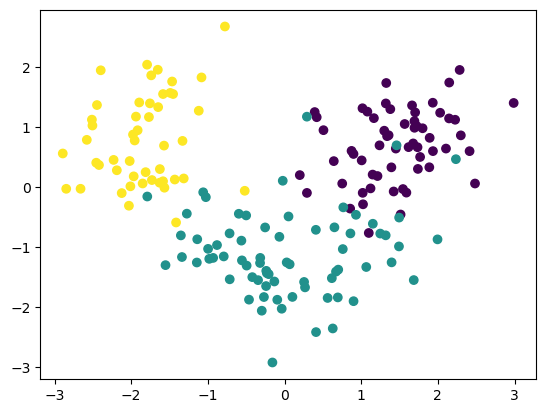

In [61]:
# 와인데이터 정답(품질)을 제거한후  k-means로 클러스터를 분리.. 최적의 k를 찾아보세요
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
pipe = Pipeline([
    ('scaler',RobustScaler()),('pca',PCA(n_components=2))
])
X_preprocess = pipe.fit_transform(X)
plt.scatter(X_preprocess[:,0],X_preprocess[:,1],c=y)
plt.show()

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

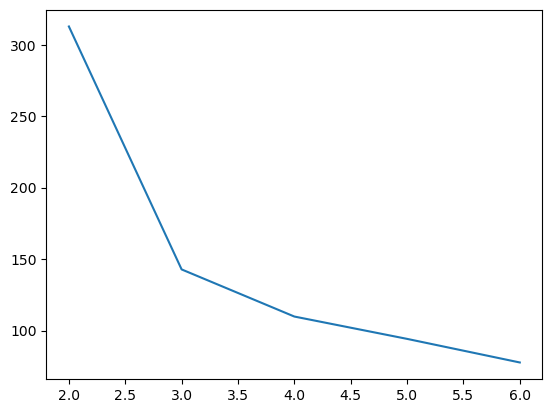

In [62]:
from sklearn.cluster import KMeans
k_range = range(2,7)
ellbows = []
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_preprocess)
    ellbows.append(model.inertia_)
plt.plot(k_range, ellbows)

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

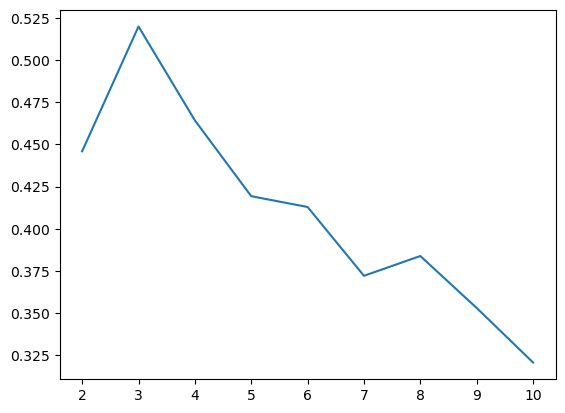

In [63]:
from sklearn.metrics import silhouette_score
scores = []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    lables = kmeans.fit_predict(X_preprocess)
    score = silhouette_score(X_preprocess,lables)
    scores.append(score)
plt.plot(k_range, scores) 

In [48]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.
